# Example 10: Rule Inactivation Sensitivity Analysis — Pancreatic Cancer Invasion Model 

[(GitHub link)](https://github.com/heberlr/UQ_PhysiCell/tree/main/examples/epi_caf_invasion/ex10_CoCulture.ipynb)

This notebook presents a custom sensitivity analysis of rule inactivation in the model developed in [Johnson et al. 2025](https://doi.org/10.1016/j.cell.2025.06.048), which represents pancreatic cancer invasion mediated by fibroblast-ECM interactions. The analysis uses an OAT-style perturbation: starting from the nominal model (all rules active), one rule is inactivated at a time, and the deviation in model outputs relative to the full model is quantified using RMSD.

**What you will learn:**
- How to encode categorical/rule-based perturbations as samples in a `ModelAnalysisContext` database
- How to use `load_samples` and `calculate_qoi_statistics` on a raw-MCDS database (Mode B from ex2)
- How to compute and normalize RMSD across multiple initial conditions for interpretable rule ranking
- How to visualize cell spatial distributions with `plot_cells_2D`

**Rules analyzed** (one inactivated at a time):

| Rule | Description |
|---|---|
| Epi. Normal CIP | Contact inhibition of proliferation in normal epithelial cells |
| EMT Normal cell | Epithelial-to-mesenchymal transition in normal epithelial cells |
| MET Normal cell | Inhibition of mesenchymal-to-epithelial transition in normal mesenchymal cells |
| Slow/Speed up N-MC | Motility modulation of normal mesenchymal cells |
| Slow/Speed up CAF | Motility modulation of cancer-associated fibroblasts |
| Epi. Tumor CIP | Contact inhibition of proliferation in epithelial tumor cells |
| EMT/MET Tumor cell | EMT and MET transitions in tumor cells |
| Slow/Speed up TA-MC | Motility modulation of tumor-associated mesenchymal cells |

Simulations were run across 7 initial conditions (epithelial tumor cell-to-CAF seeding ratios with 1,000 total cells), simulated for 7 days with multiple stochastic replicates.

In [1]:
from uq_physicell.model_analysis import calculate_qoi_statistics

db_file = 'uq_Simulations_OAT_CoCulture.db'

# df_cell → cell DataFrame (see ex1 for the full dispatch table)
qoi_funcs = {
    'epi_normal_cell_count':    lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'epithelial_normal')]),
    'mesenc_normal_cell_count': lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'mesenchymal_normal')]),
    'fibroblast_cell_count':    lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'fibroblast')]),
    'epi_tumor_cell_count':     lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'epithelial_tumor')]),
    'mesenc_tumor_cell_count':  lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'mesenchymal_tumor')]),
    'epi_normal_radial_dist':   lambda df_cell: df_cell[df_cell['cell_type'] == 'epithelial_normal'][['position_x','position_y','position_z']].apply(lambda r: (r**2).sum()**0.5, axis=1).mean(),
    'mesenc_normal_radial_dist':lambda df_cell: df_cell[df_cell['cell_type'] == 'mesenchymal_normal'][['position_x','position_y','position_z']].apply(lambda r: (r**2).sum()**0.5, axis=1).mean(),
    'fibroblast_radial_dist':   lambda df_cell: df_cell[df_cell['cell_type'] == 'fibroblast'][['position_x','position_y','position_z']].apply(lambda r: (r**2).sum()**0.5, axis=1).mean(),
    'epi_tumor_radial_dist':    lambda df_cell: df_cell[df_cell['cell_type'] == 'epithelial_tumor'][['position_x','position_y','position_z']].apply(lambda r: (r**2).sum()**0.5, axis=1).mean(),
    'mesenc_tumor_radial_dist': lambda df_cell: df_cell[df_cell['cell_type'] == 'mesenchymal_tumor'][['position_x','position_y','position_z']].apply(lambda r: (r**2).sum()**0.5, axis=1).mean(),
}

# ignore_db_consistency=True because 2 samples are missing from the Output table
df_summary_mean, df_summary_std, df_summary_mcse = calculate_qoi_statistics(db_file, qoi_funcs, ignore_db_consistency=True)
display(df_summary_mean)

No QoI data provided, calculating QoIs from the database...
2 from Samples table is missing in Output table.
 Missing SampleIDs: [61, 62]
Calculating QoIs from mcds list...


epi_normal_cell_count  epi_normal_radial_dist  \
SampleID time                                                     
0        0.0                        0.0                     NaN   
         1440.0                     0.0                     NaN   
         2880.0                     0.0                     NaN   
         4320.0                     0.0                     NaN   
         5760.0                     0.0                     NaN   
...                                 ...                     ...   
90       4320.0                     0.0                     NaN   
         5760.0                     0.0                     NaN   
         7200.0                     0.0                     NaN   
         8640.0                     0.0                     NaN   
         10080.0                    0.0                     NaN   

                  epi_tumor_cell_count  epi_tumor_radial_dist  \
SampleID time                                                   
0        0.0                     500.0             192.045556   
         1440.0                   35.6             283.491670   
         2880.0                   49.4             330.193621   
         4320.0                   90.8             354.745680   
         5760.0                  150.0             379.339727   
...                                ...                    ...   
90       4320.0                 2126.6             279.996736   
         5760.0                 2687.0             313.017651   
         7200.0                 3342.4             346.349592   
         8640.0                 4084.4             379.990875   
         10080.0                4896.0             413.570264   

                  fibroblast_cell_count  fibroblast_radial_dist  \
SampleID time                                                     
0        0.0                      500.0              183.661279   
         1440.0                   500.0              195.036377   
         2880.0                   500.0              203.653420   
         4320.0                   500.0              211.526886   
         5760.0                   500.0              218.391999   
...                                 ...                     ...   
90       4320.0                    90.0              218.673131   
         5760.0                    90.0              223.993993   
         7200.0                    90.0              229.256590   
         8640.0                    90.0              231.584211   
         10080.0                   90.0              233.510260   

                  mesenc_normal_cell_count  mesenc_normal_radial_dist  \
SampleID time                                                           
0        0.0                           0.0                        NaN   
         1440.0                        0.0                        NaN   
         2880.0                        0.0                        NaN   
         4320.0                        0.0                        NaN   
         5760.0                        0.0                        NaN   
...                                    ...                        ...   
90       4320.0                        0.0                        NaN   
         5760.0                        0.0                        NaN   
         7200.0                        0.0                        NaN   
         8640.0                        0.0                        NaN   
         10080.0                       0.0                        NaN   

                  mesenc_tumor_cell_count  mesenc_tumor_radial_dist  
SampleID time                                                        
0        0.0                          0.0                       NaN  
         1440.0                     544.6                205.741238  
         2880.0                     567.8                218.598059  
         4320.0                     586.6                230.352639  
         5760.0                     618.6                2

## Map sample IDs to rules and initial conditions

In [2]:
from uq_physicell.model_analysis import load_samples
import pandas as pd

# Normalize the QOIs by the nominal case (row with all rules activated)
dic_parameters = load_samples(db_file)
df_samples_desc = pd.DataFrame.from_dict(dic_parameters, orient='index')
df_samples_desc.index.name = 'SampleID'
df_samples_desc['Inactive_rule'] = df_samples_desc.apply(
    lambda row: next((key for key, value in row.items() if key != 'IC_file' and value == 1), None),
    axis=1
)
# Drop the original parameter columns, keeping only 'IC_file' and 'Inactive_rule'
df_samples_desc = df_samples_desc[['IC_file', 'Inactive_rule']]
dic_rules_names = { 'epi_normal_rule_pressureDcellcycle_inactive': 'Epi. Normal CIP', # Contact inhibition of proliferation in normal epithelial cells
                   'epi_normal_rule_ecmImesenc_normal_inactive': 'EMT Normal cell', # Transition from epithelial to mesenchymal state (EMT) in normal epithelial cells
                   'mesenc_normal_rule_ecmDspeed_inactive': 'Slow down N-MC', # Slow down normal mesenchymal cells (N-MC) by decreasing their speed
                   'mesenc_normal_rule_ecmIspeed_inactive': 'Speed up N-MC', # Speed up normal mesenchymal cells (N-MC) by increasing their speed
                   'mesenc_normal_rule_infsignalDepi_normal_inactive': 'MET Normal cell', # Inhibition of transition from mesenchymal state to epithelial (MET) in normal mesenchymal cells (N-MC)
                   'fib_rule_ecmDspeed_inactive': 'Slow down CAF', # Slow down cancer-associated fibroblasts (CAF) by decreasing their speed
                   'fib_rule_ecmIspeed_inactive': 'Speed up CAF', # Speed up cancer-associated fibroblasts (CAF) by increasing their speed
                   'epi_tumor_rule_pressureDcellcycle_inactive': 'Epi. Tumor CIP', # Contact inhibition of proliferation in tumor epithelial cells
                   'epi_tumor_rule_ecmImesenc_tumor_inactive': 'EMT Tumor cell', # Transition from epithelial to mesenchymal state (EMT) in tumor epithelial cells
                   'mesenc_tumor_rule_ecmDspeed_inactive': 'Slow down TA-MC', # Slow down tumor associated mesenchymal cells (TA-MC) by decreasing their speed
                   'mesenc_tumor_rule_ecmIspeed_inactive': 'Speed up TA-MC', # Speed up tumor associated mesenchymal cells (TA-MC) by increasing their speed
                   'mesenc_tumor_rule_infsignalDepi_tumor_inactive': 'MET Tumor cell', # Inhibition of transition from mesenchymal state to epithelial (MET) in tumor mesenchymal cells
                    }
# Rename the Inactive_rule values based on the dic_rules_names mapping
df_samples_desc['Inactive_rule'] = df_samples_desc['Inactive_rule'].map(dic_rules_names).fillna(df_samples_desc['Inactive_rule'])
display(df_samples_desc)

,IC_file,Inactive_rule
SampleID,,
0,cells_1_to_1.csv,None
1,cells_1_to_2.csv,None
2,cells_1_to_5.csv,None
3,cells_1_to_10.csv,None
4,cells_2_to_1.csv,None
...,...,...
86,cells_1_to_5.csv,MET Tumor cell
87,cells_1_to_10.csv,MET Tumor cell
88,cells_2_to_1.csv,MET Tumor cell


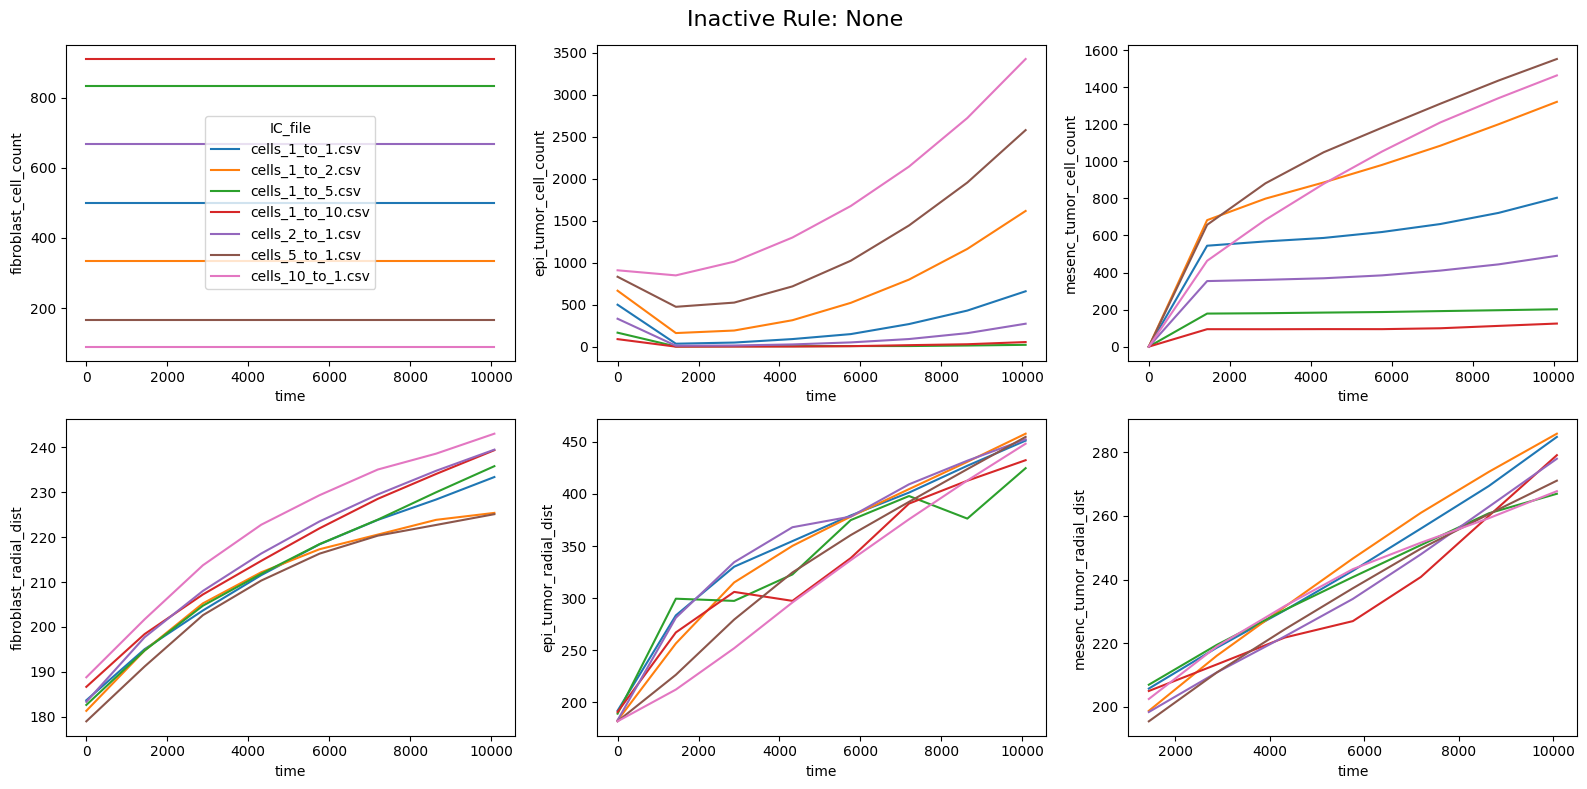

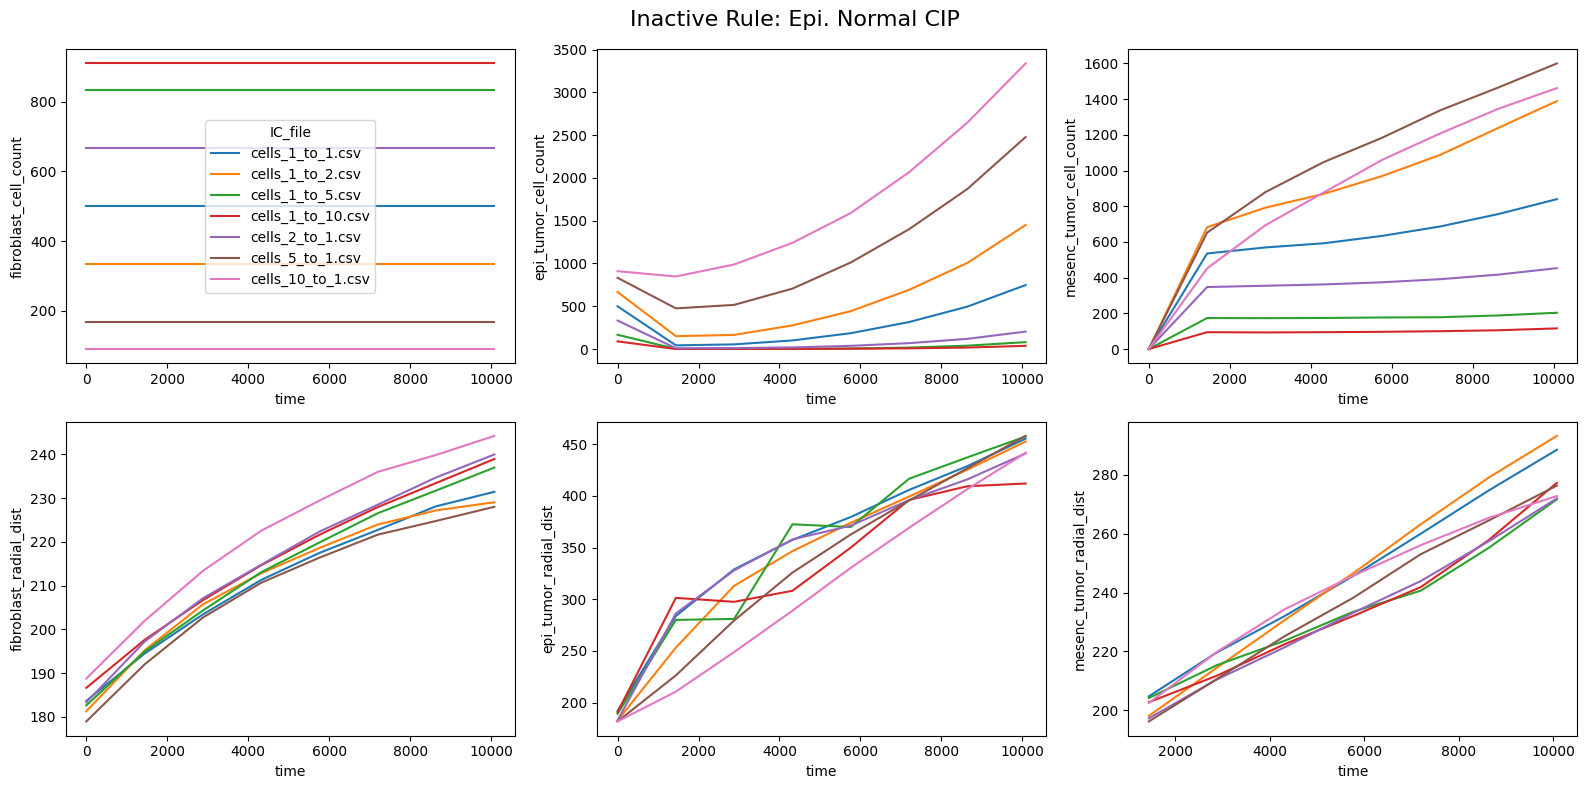

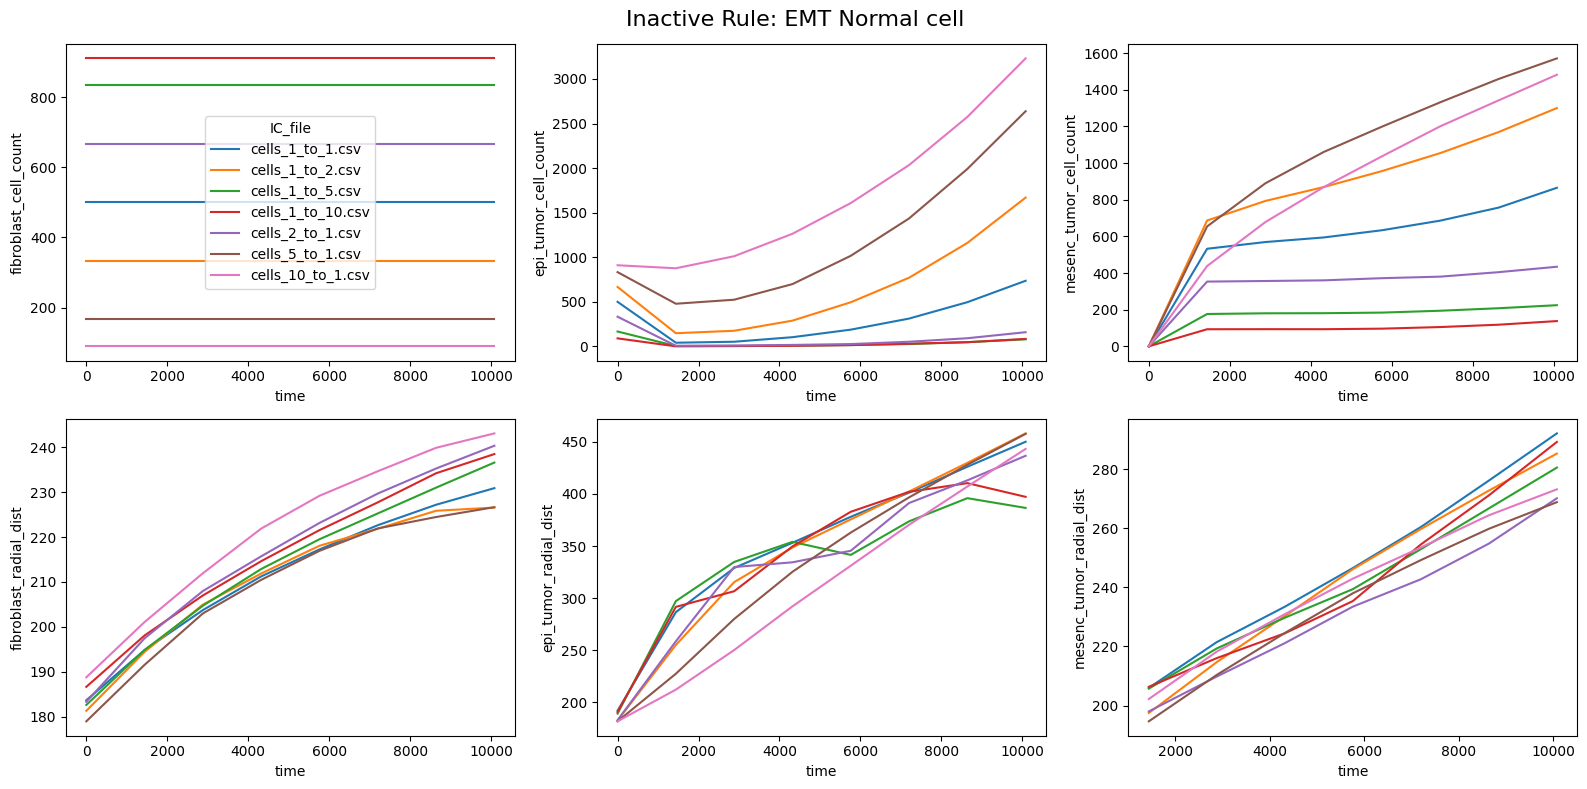

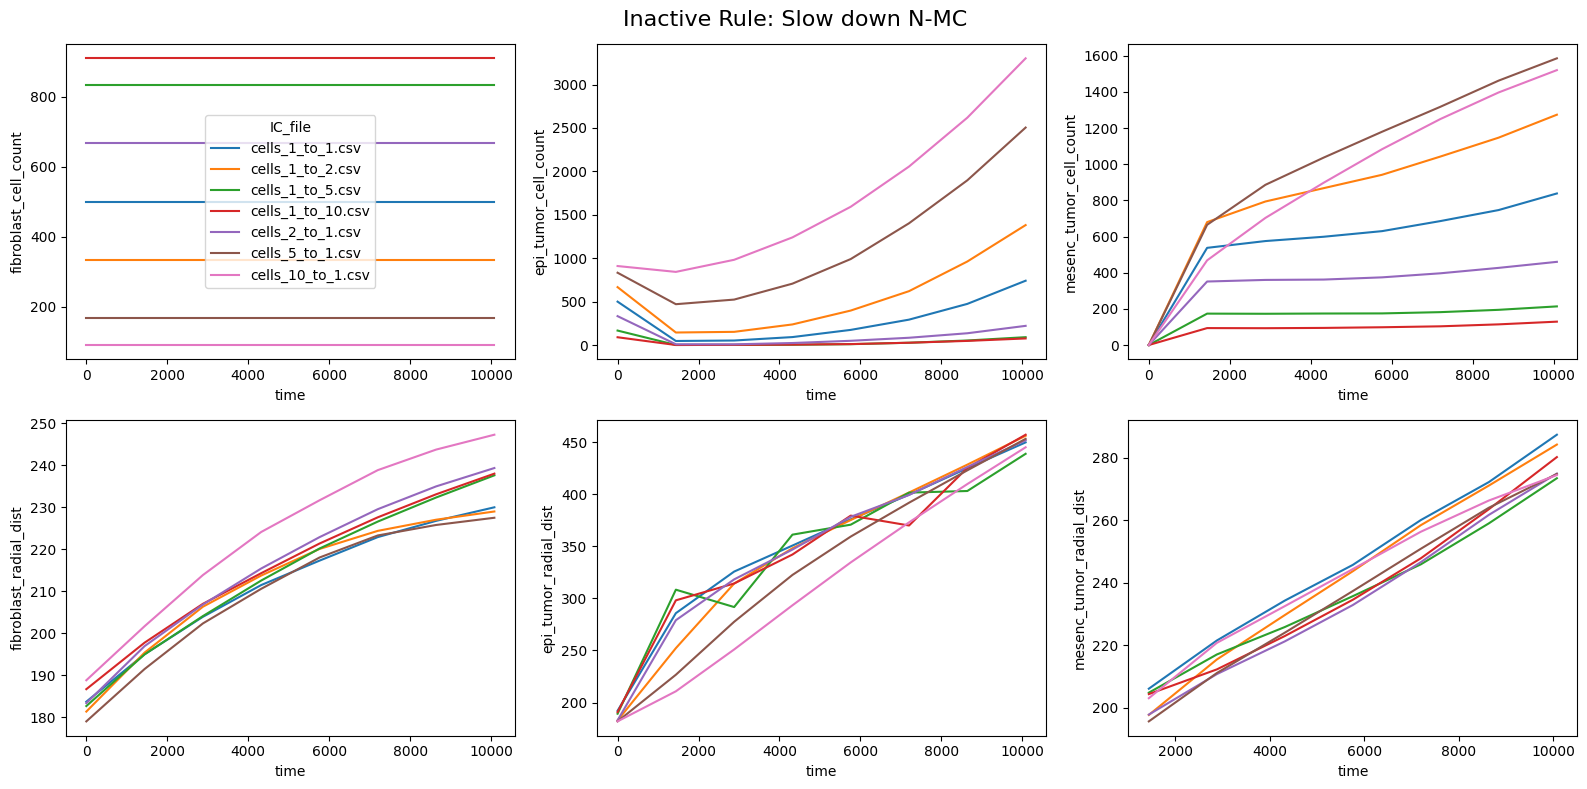

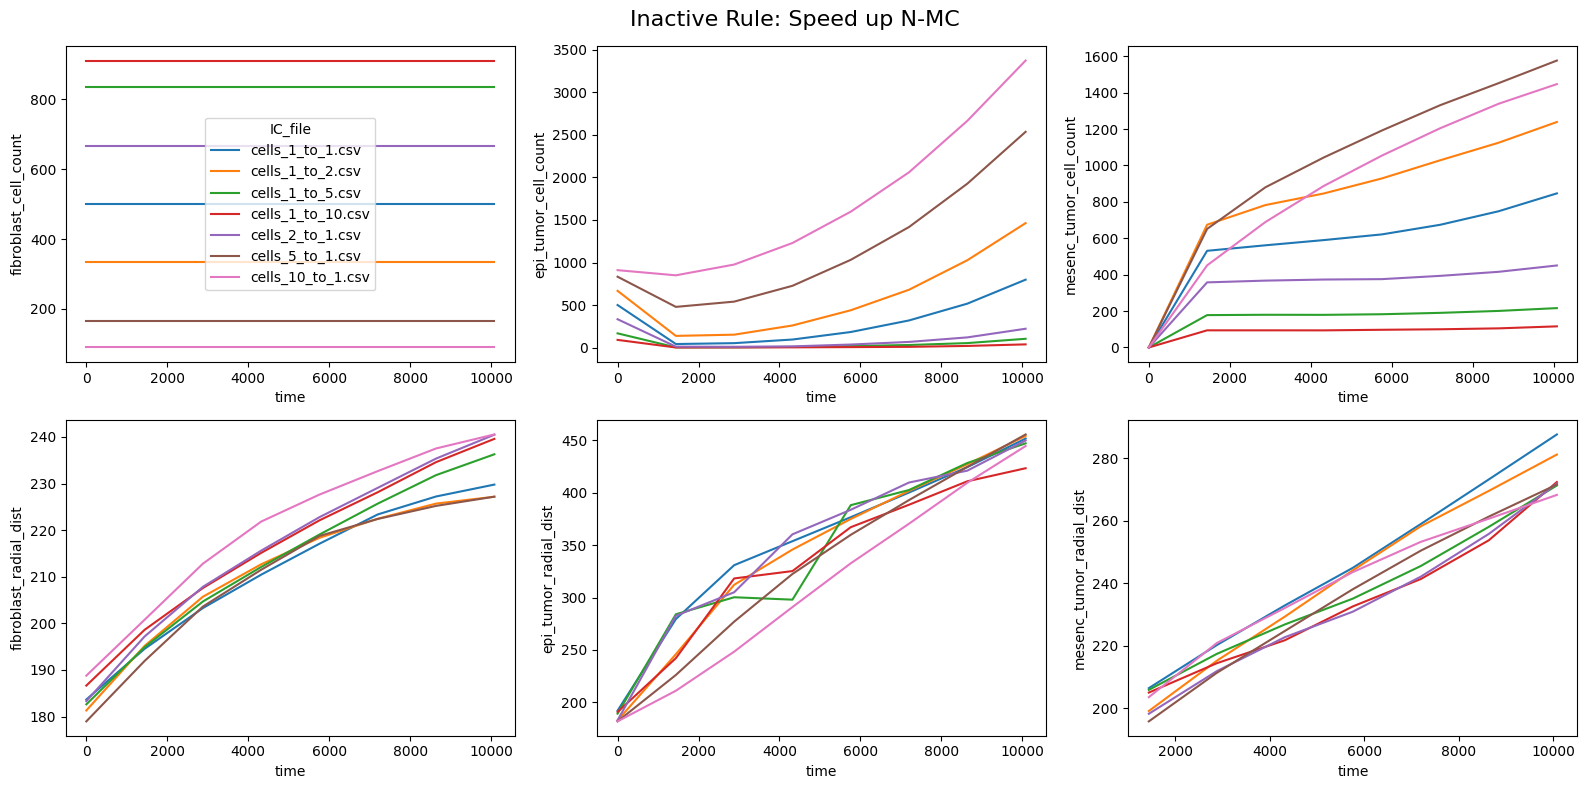

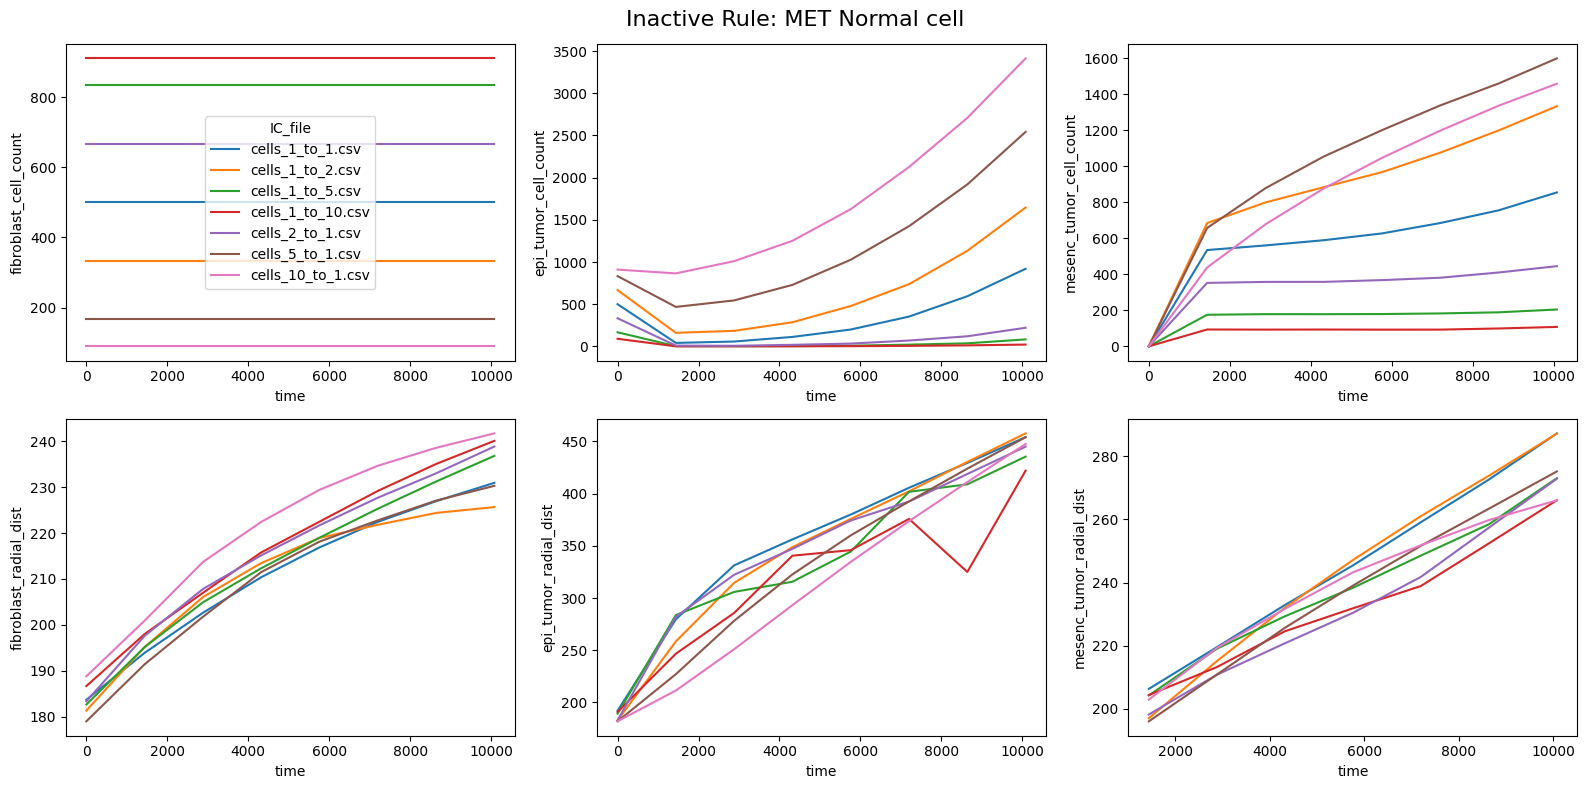

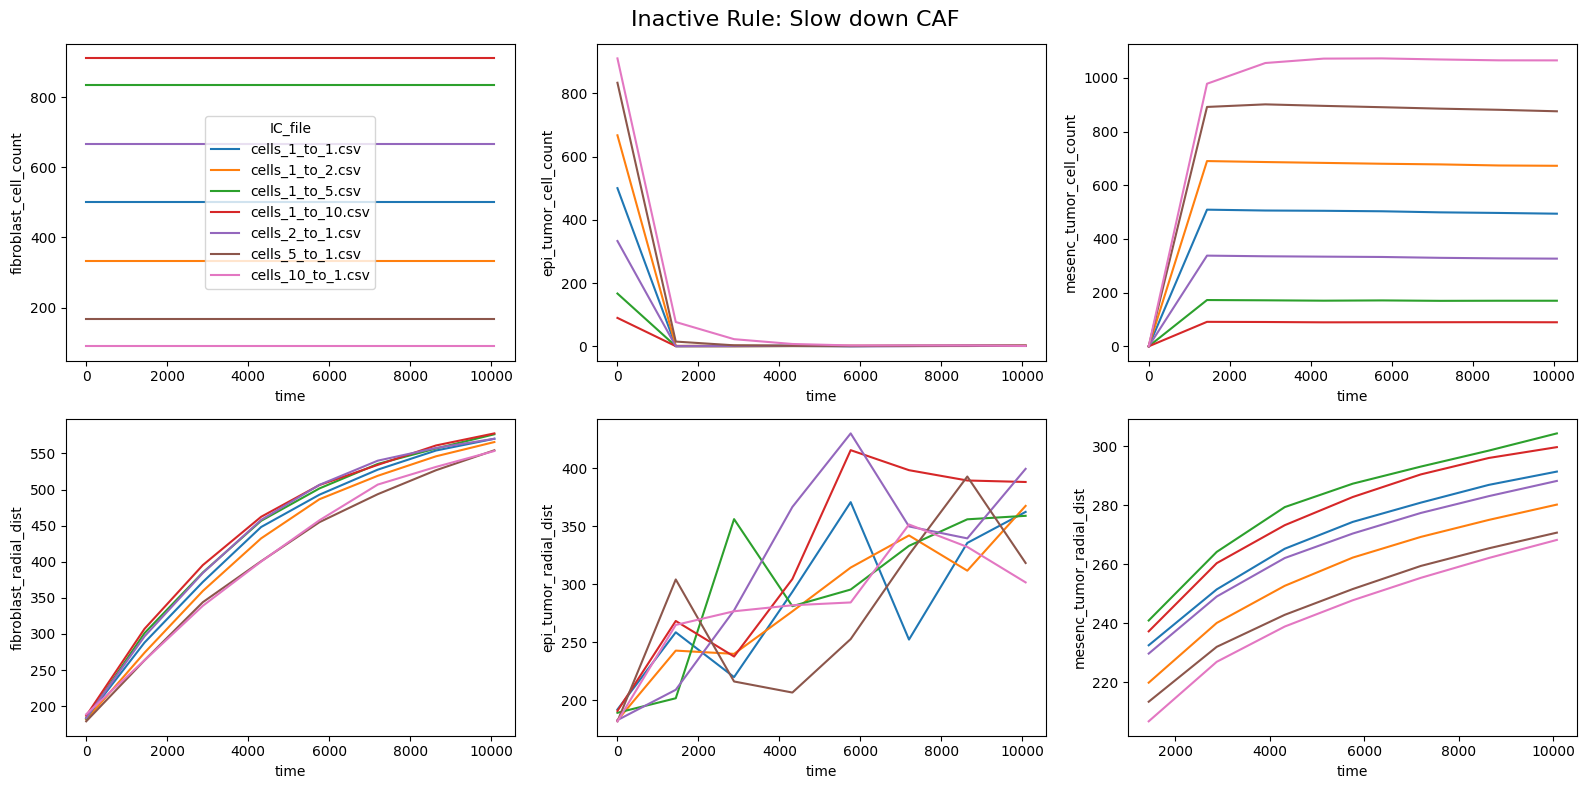

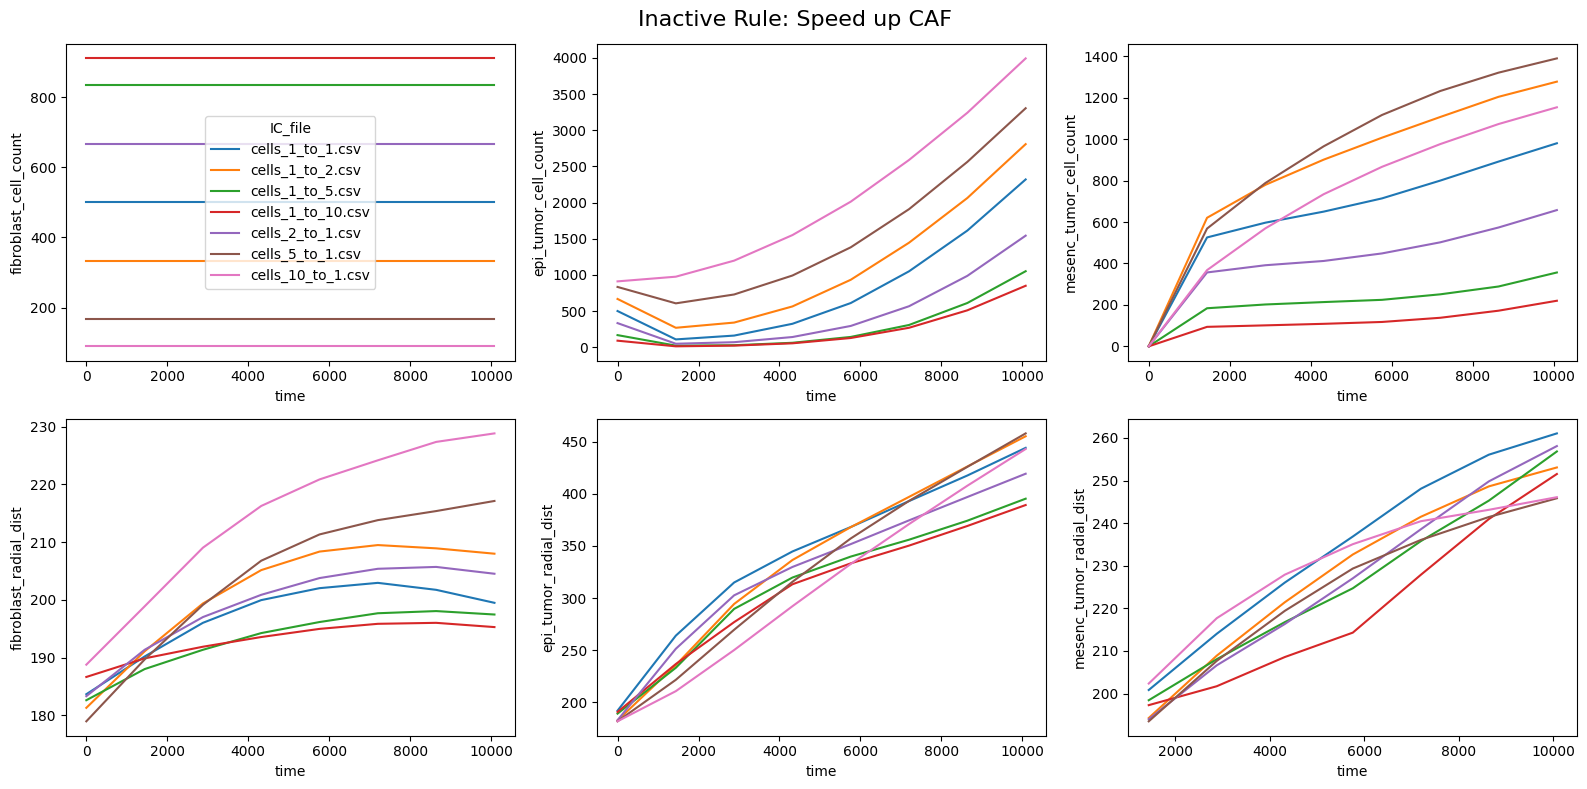

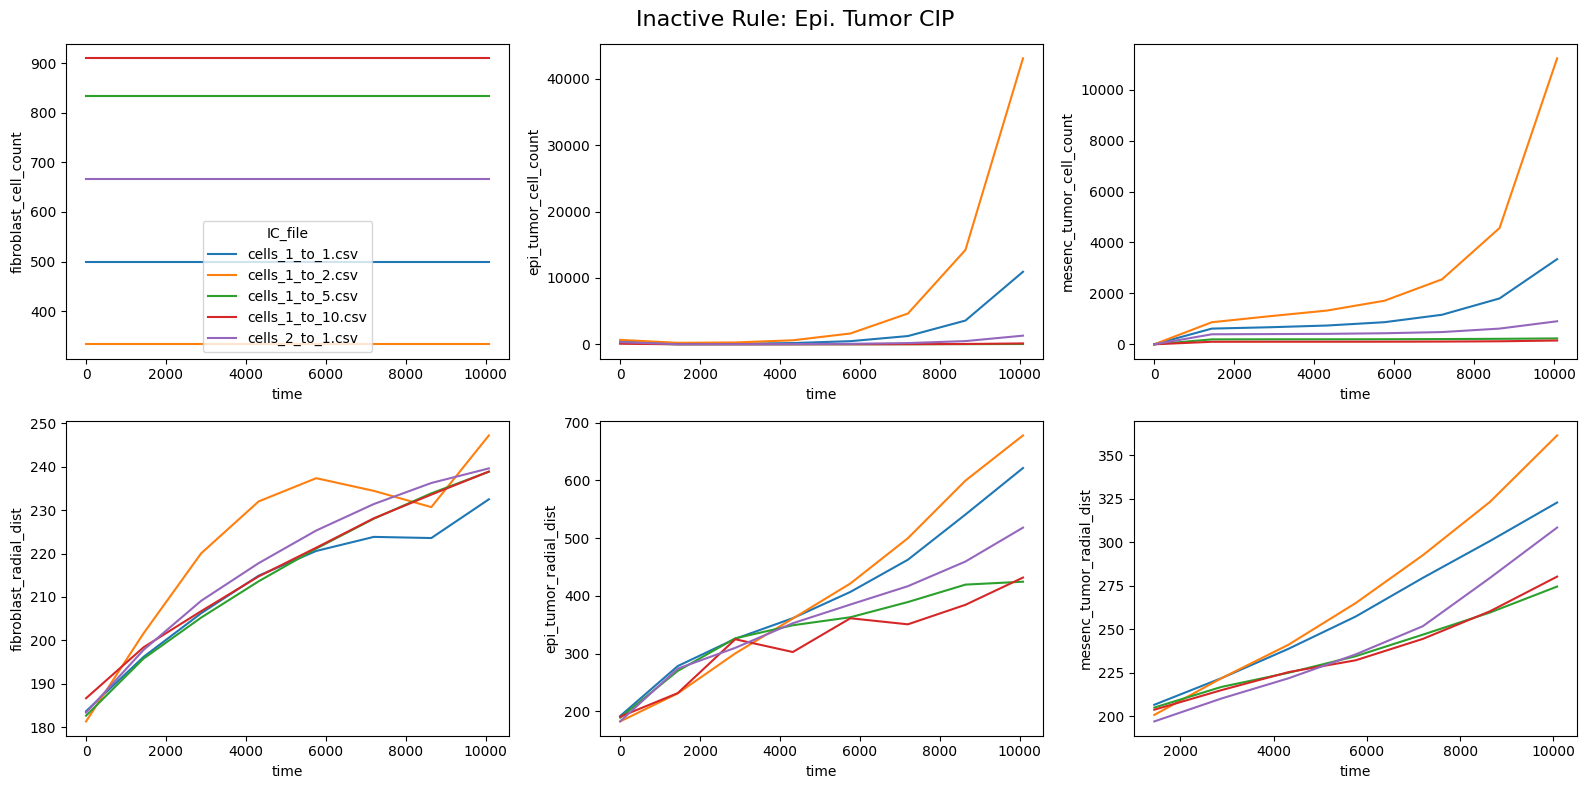

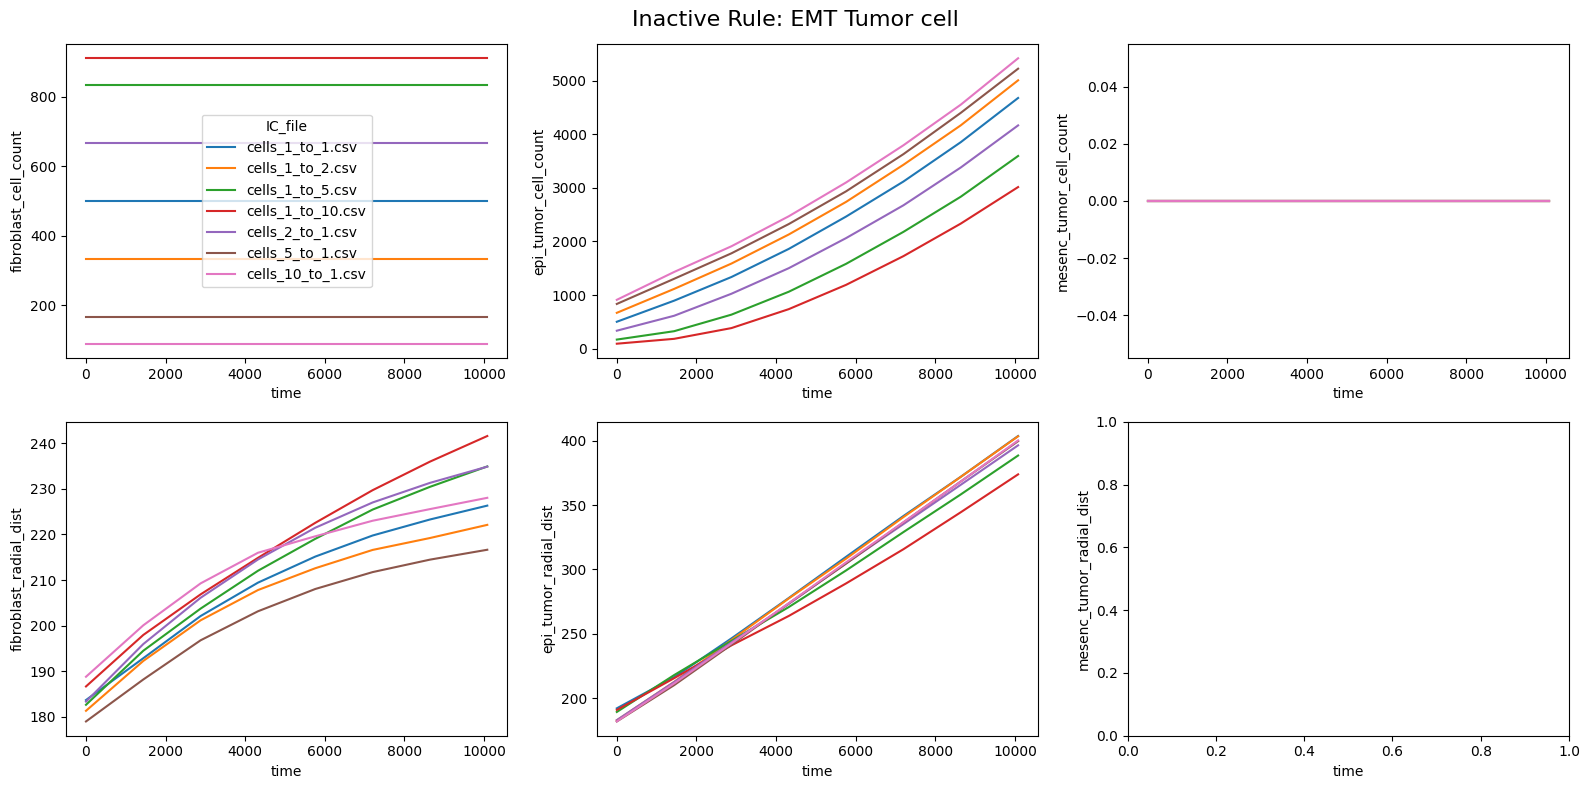

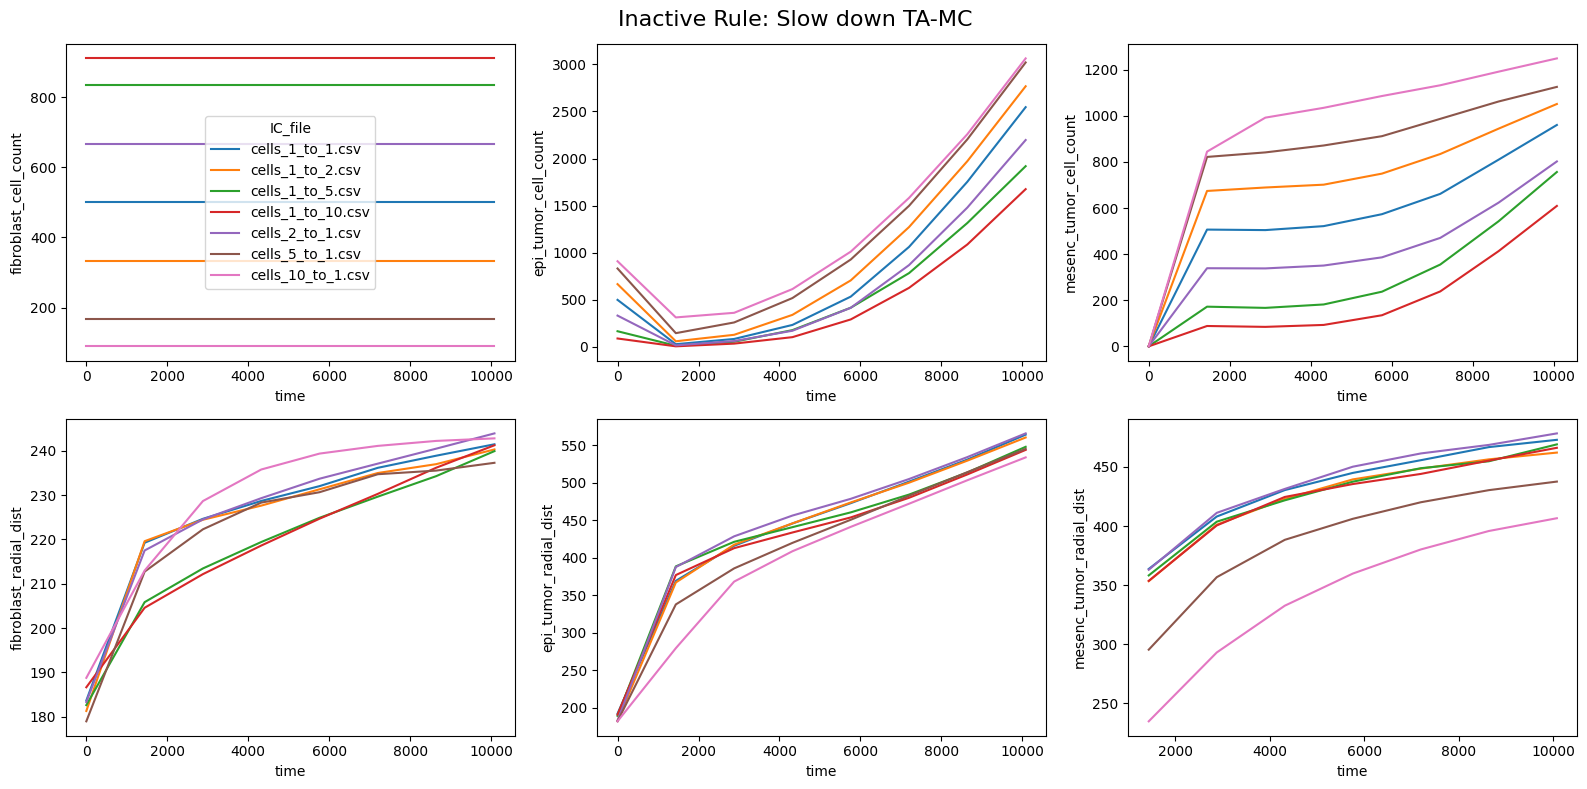

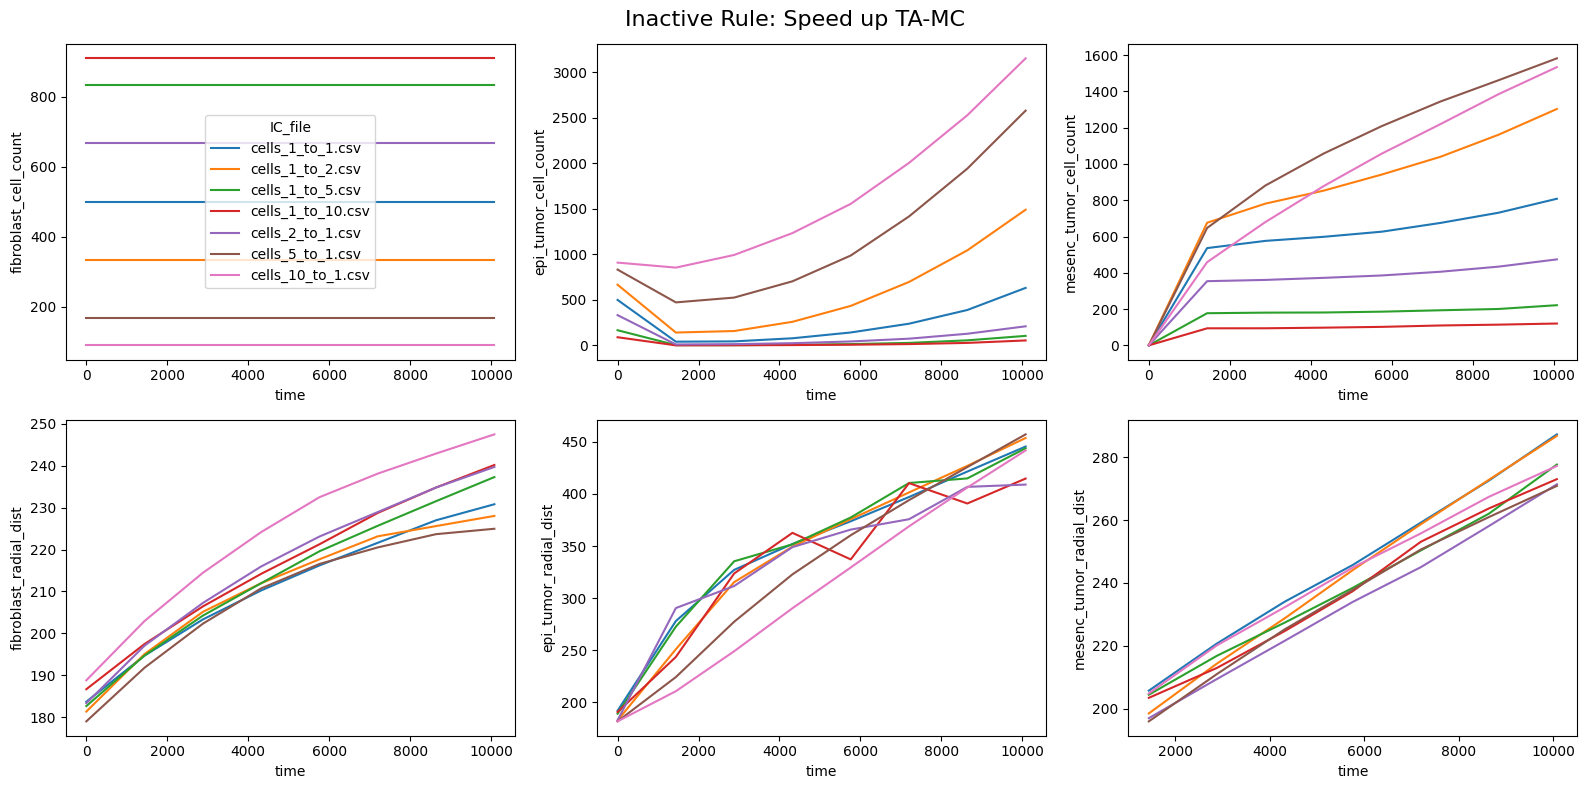

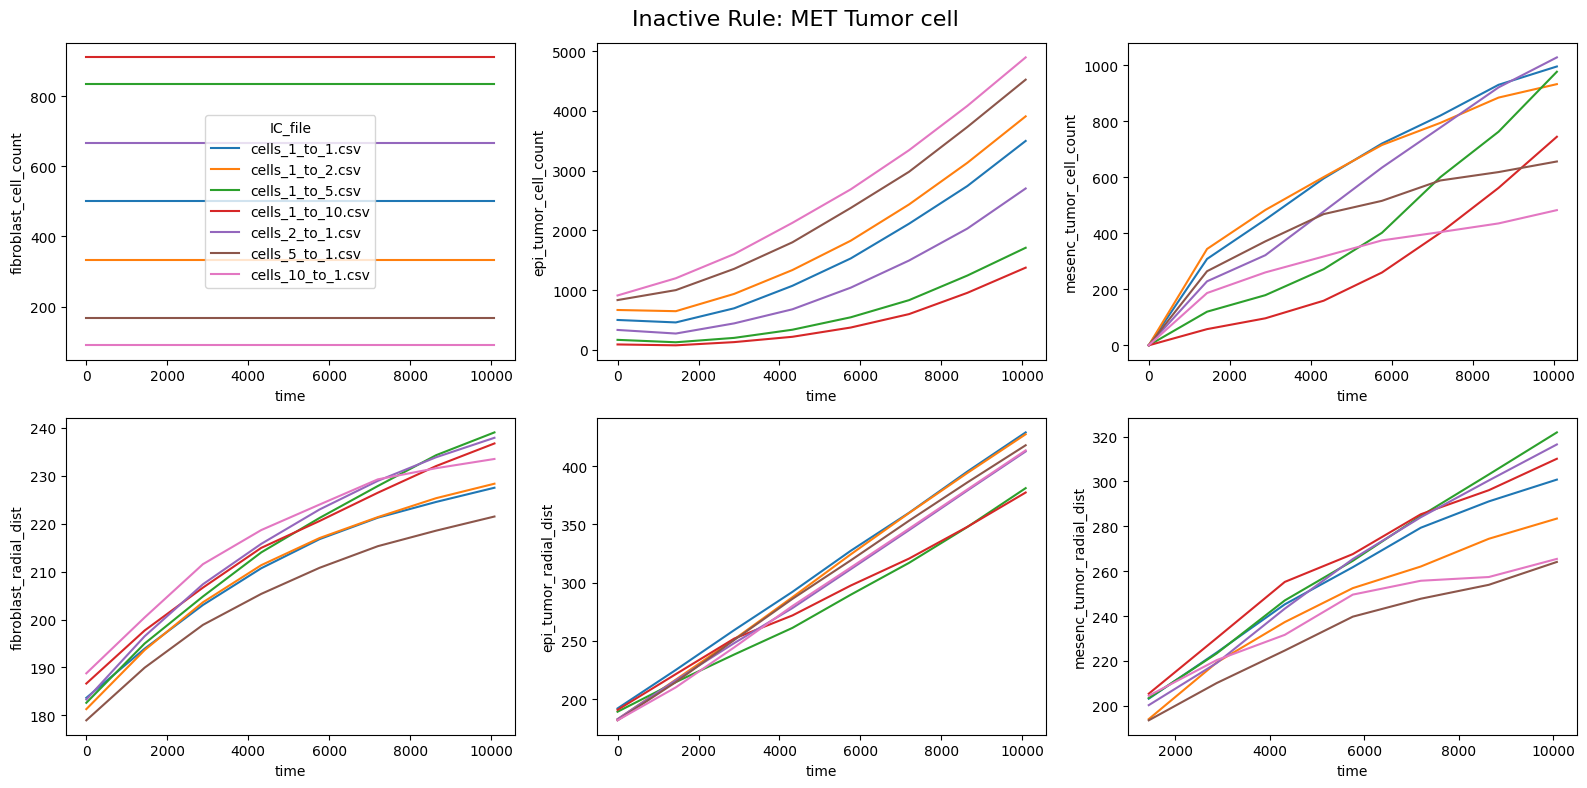

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette for different initial conditions
palette = sns.color_palette("colorblind")
my_palette = {}
for ic in df_samples_desc['IC_file'].unique():
    my_palette[ic] = palette[len(my_palette) % len(palette)]
# Make sure 'time' is a column in df_summary_mean for plotting
df_summary_mean_ = df_summary_mean.reset_index('time')
# Include the mapping of SampleID to IC_file in df_summary_mean for plotting
df_summary_mean_["IC_file"] = df_summary_mean_.index.map(df_samples_desc['IC_file'])
qois_with_changes = [ col for col in qoi_funcs.keys() if (df_summary_mean_[col].max() != df_summary_mean_[col].min()) and (col != 'time') and not pd.isnull(df_summary_mean_[col].max()) ]  # Identify QoIs that have changes across samples (exclude time column)
for inac_rule in df_samples_desc['Inactive_rule'].unique():
    fig, axes = plt.subplots(2,3,figsize=(16, 8))
    axes_f = axes.flatten()
    fig.suptitle(f'Inactive Rule: {inac_rule}', fontsize=16)
    if inac_rule is None: df_summary_qois_plot = df_summary_mean_.loc[df_samples_desc['Inactive_rule'].isna()].reset_index()  # Filter for the nominal case (all rules active)
    else: df_summary_qois_plot = df_summary_mean_.loc[df_samples_desc['Inactive_rule'] == inac_rule].reset_index()  # Filter for inactive rule
    for id_qoi, qoi in enumerate(qois_with_changes):
        sns.lineplot(data=df_summary_qois_plot, x="time", y=qoi, hue="IC_file", ax=axes_f[id_qoi], legend=True if id_qoi==0 else False)
    fig.tight_layout()
    plt.savefig(f'CoCulture_QoIs_{inac_rule}.svg', format='svg')

## Compute RMSD relative to the nominal (all-rules-active) model

In [4]:
import pandas as pd
import numpy as np

# Use SampleID as the main index; time stays as a column for alignment within each sample
qoi_cols = list(qoi_funcs.keys())
df_rmsd = pd.DataFrame(index=df_samples_desc.index, columns=qoi_cols, dtype=float)
for ic_file in df_samples_desc['IC_file'].unique():
    sampleids = df_samples_desc.index[df_samples_desc['IC_file'] == ic_file].tolist()
    nominal_sampleid = df_samples_desc.index[(df_samples_desc['IC_file'] == ic_file) & (df_samples_desc['Inactive_rule'].isna())].tolist()[0]  # SampleID for the nominal case (all rules active)
    samples_missing = [sid for sid in sampleids if sid not in df_summary_mean_.index]
    samples_present = [sid for sid in sampleids if sid in df_summary_mean_.index]
    print(f"Taking the squared difference of IC_file: {ic_file} with nominal SampleID: {nominal_sampleid}. Samples missing: {samples_missing}")

    nominal_qois = df_summary_mean_.loc[nominal_sampleid, ['time'] + qoi_cols].set_index('time')
    for sid in samples_present:
        current_qois = df_summary_mean_.loc[sid, ['time'] + qoi_cols].set_index('time')
        common_time = current_qois.index.intersection(nominal_qois.index)
        if len(common_time) == 0:
            continue
        df_rmsd.loc[sid, qoi_cols] = np.sqrt(((current_qois.loc[common_time, qoi_cols] - nominal_qois.loc[common_time, qoi_cols]) ** 2).mean())

df_rmsd = df_rmsd.fillna(0)  # Fill NaN values with 0 for samples that are missing (since we cannot calculate RMSD without data, we set it to 0 to indicate no deviation from nominal)
display("RMSD: ", df_rmsd)

Taking the squared difference of IC_file: cells_1_to_1.csv with nominal SampleID: 0. Samples missing: []
Taking the squared difference of IC_file: cells_1_to_2.csv with nominal SampleID: 1. Samples missing: []
Taking the squared difference of IC_file: cells_1_to_5.csv with nominal SampleID: 2. Samples missing: []
Taking the squared difference of IC_file: cells_1_to_10.csv with nominal SampleID: 3. Samples missing: []
Taking the squared difference of IC_file: cells_2_to_1.csv with nominal SampleID: 4. Samples missing: []
Taking the squared difference of IC_file: cells_5_to_1.csv with nominal SampleID: 5. Samples missing: [61]
Taking the squared difference of IC_file: cells_10_to_1.csv with nominal SampleID: 6. Samples missing: [62]


'RMSD: '

,epi_normal_cell_count,mesenc_normal_cell_count,fibroblast_cell_count,epi_tumor_cell_count,mesenc_tumor_cell_count,epi_normal_radial_dist,mesenc_normal_radial_dist,fibroblast_radial_dist,epi_tumor_radial_dist,mesenc_tumor_radial_dist
SampleID,,,,,,,,,,
0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
2,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
3,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
4,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
86,0.0,0.0,0.0,828.170426,378.092733,0.0,0.0,2.683751,62.263029,31.207755
87,0.0,0.0,0.0,626.444774,297.970057,0.0,0.0,1.496992,49.312425,32.315537
88,0.0,0.0,0.0,1275.408850,304.361348,0.0,0.0,0.858326,63.920350,28.567824


## Normalize and plot RMSD per rule and initial condition

Valid columns: Index(['epi_tumor_cell_count', 'mesenc_tumor_cell_count',
       'fibroblast_radial_dist', 'epi_tumor_radial_dist',
       'mesenc_tumor_radial_dist'],
      dtype='object')


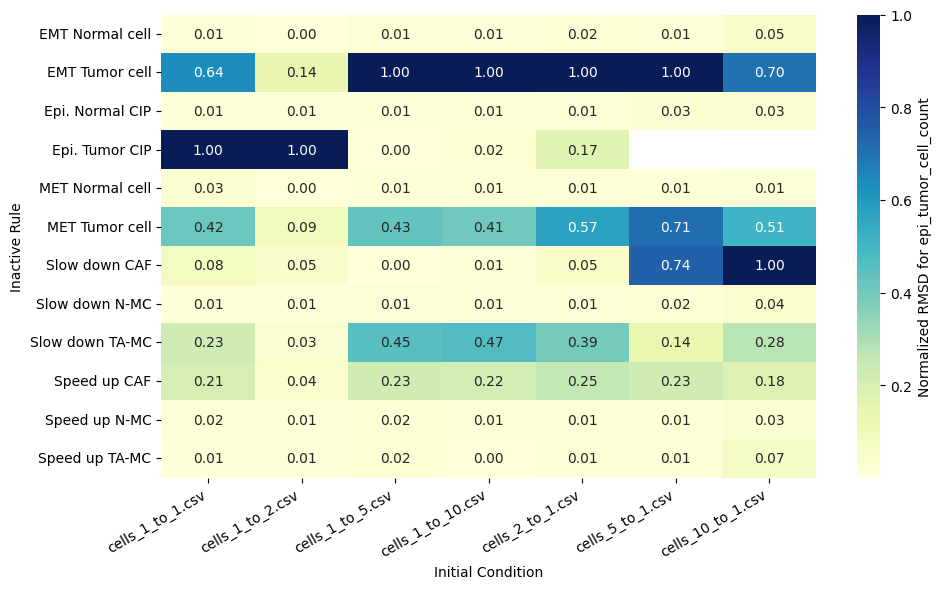

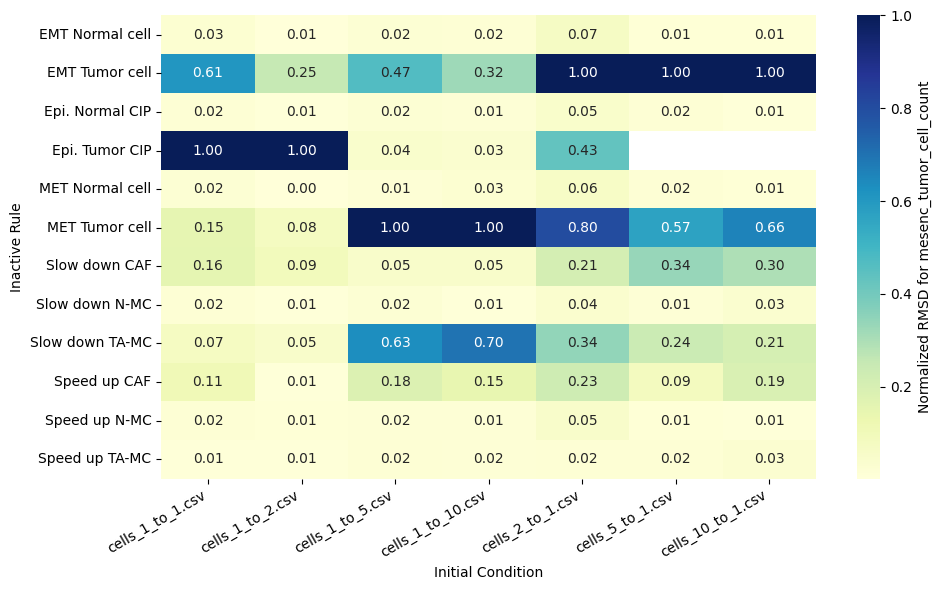

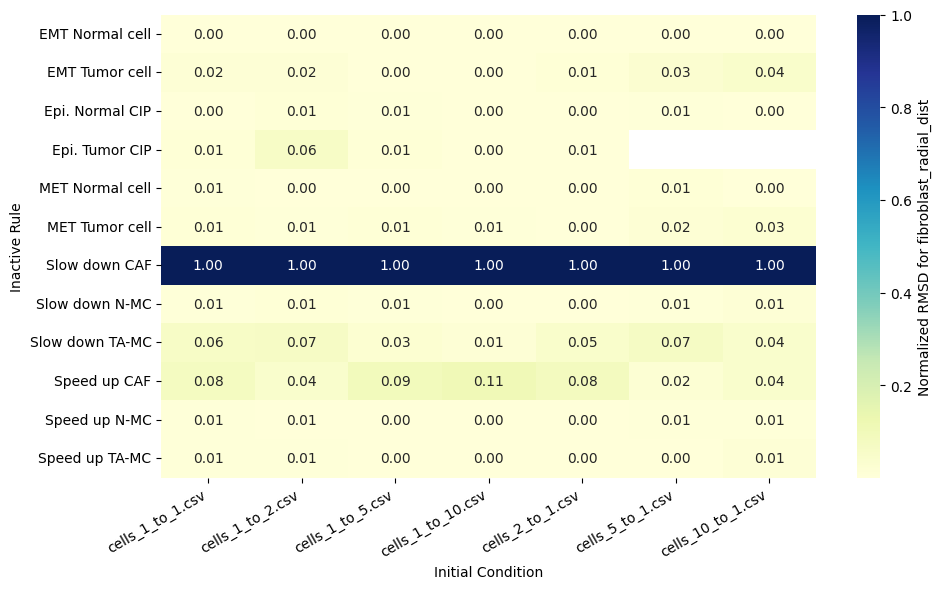

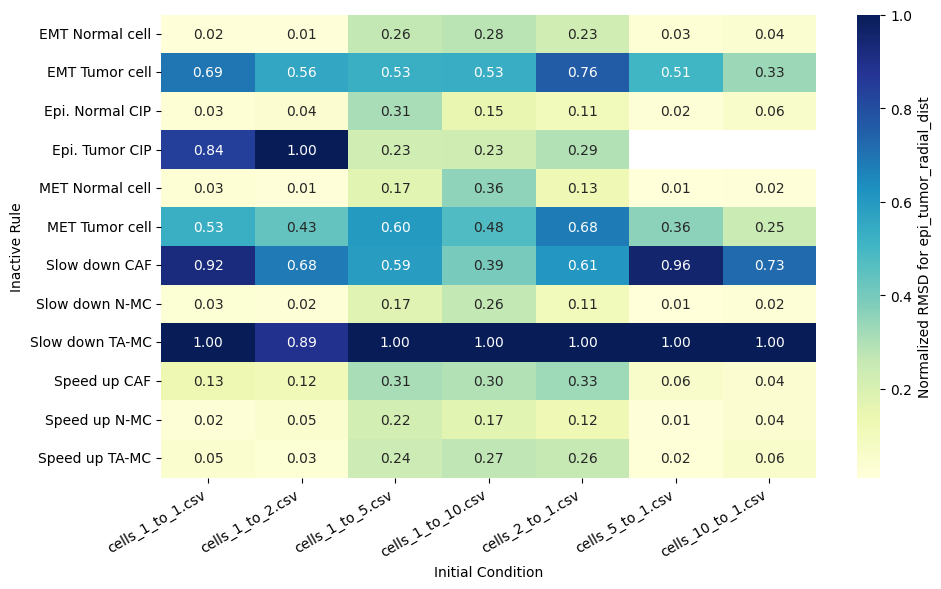

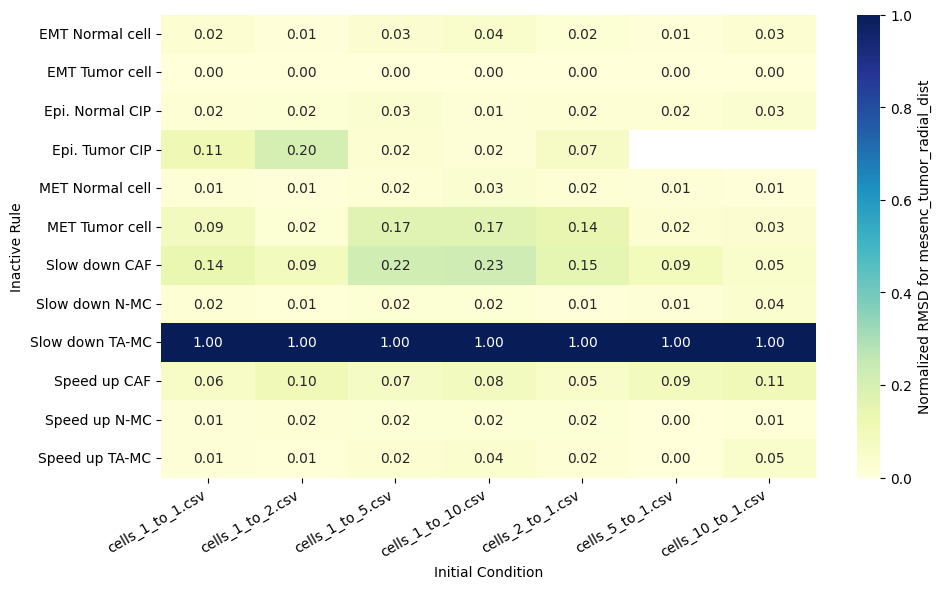

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Normalize per column and IC (each QOI independently for better visualization)
df_rmsd_normalized = pd.DataFrame(index=df_rmsd.index, columns=df_rmsd.columns, dtype=float)
for ic_file in df_samples_desc['IC_file'].unique():
    sampleids = df_samples_desc.index[df_samples_desc['IC_file'] == ic_file].tolist()
    samples_present = [sid for sid in sampleids if sid in df_summary_mean_.index]
    # Feature-wise normalization for the current IC (divide by the range of each column for the samples of the same IC) - Normalized RMSD (NRMSD)
    df_rmsd_normalized.loc[samples_present] = df_rmsd.loc[samples_present] / (df_rmsd.loc[samples_present].max(axis=0) - df_rmsd.loc[samples_present].min(axis=0))

# Remove columns with all NaN values
df_rmsd_normalized = df_rmsd_normalized.dropna(axis='columns', how='all')
# Replace NaN values (from zero-range normalization) with 0
valid_columns = df_rmsd_normalized.columns
print(f"Valid columns: {valid_columns}")

# Include IC_file and Inactive_rule for coloring and grouping in the plot
df_rmsd_normalized['IC_file'] = df_rmsd_normalized.index.map(df_samples_desc['IC_file'])
df_rmsd_normalized['Inactive_rule'] = df_rmsd_normalized.index.map(df_samples_desc['Inactive_rule'])

ic_order = list(my_palette.keys())

for qoi in valid_columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    df_rmsd_normalized_plot = df_rmsd_normalized.sort_values(by=qoi, ascending=False)
    df_rmsd_normalized_plot = df_rmsd_normalized_plot[df_rmsd_normalized_plot['Inactive_rule'].notna()]
    # sns.boxplot(data=df_rmsd_normalized_plot, x=qoi, y="Inactive_rule", color="white", showfliers=False)
    # sns.swarmplot(data=df_rmsd_normalized_plot, x=qoi, y="Inactive_rule", hue="IC_file", color="0.25", size=6, palette=my_palette,  hue_order=my_palette.keys(), dodge=True)
    # plt.legend(title="Initial Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
    # ax.set(xlabel=f'Normalized RMSD for {qoi}', ylabel='Inactive Rule')
    heatmap_data = df_rmsd_normalized_plot.pivot(index='Inactive_rule', columns='IC_file', values=qoi).reindex(columns=ic_order)
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': f'Normalized RMSD for {qoi}'}, ax=ax)
    ax.set(xlabel='Initial Condition', ylabel='Inactive Rule')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'CoCulture_NormalizedRMSD_{qoi}.svg', format='svg')


## Rank rules by mean normalized RMSD across all QoIs

,count,mean,std,min,25%,50%,75%,max
Slow down TA-MC,7.0,0.527242,0.082545,0.408277,0.480845,0.505388,0.589553,0.636236
Slow down CAF,7.0,0.456883,0.116993,0.337297,0.378724,0.405487,0.536223,0.625503
EMT Tumor cell,7.0,0.404619,0.114585,0.193522,0.380904,0.400342,0.461467,0.553727
MET Tumor cell,7.0,0.326916,0.117214,0.126188,0.26615,0.336219,0.426064,0.441575
Epi. Tumor CIP,5.0,0.312581,0.289664,0.060066,0.062364,0.193541,0.593677,0.65326
Speed up CAF,7.0,0.132195,0.047643,0.062193,0.104834,0.115819,0.173963,0.189761
Speed up TA-MC,7.0,0.038832,0.025087,0.010794,0.01431,0.043642,0.0616,0.065565
EMT Normal cell,7.0,0.03876,0.028981,0.006251,0.015048,0.028163,0.068062,0.070685
Epi. Normal CIP,7.0,0.032798,0.021349,0.015944,0.01766,0.027006,0.037389,0.076541
MET Normal cell,7.0,0.031857,0.028217,0.005544,0.011966,0.020032,0.044144,0.085203


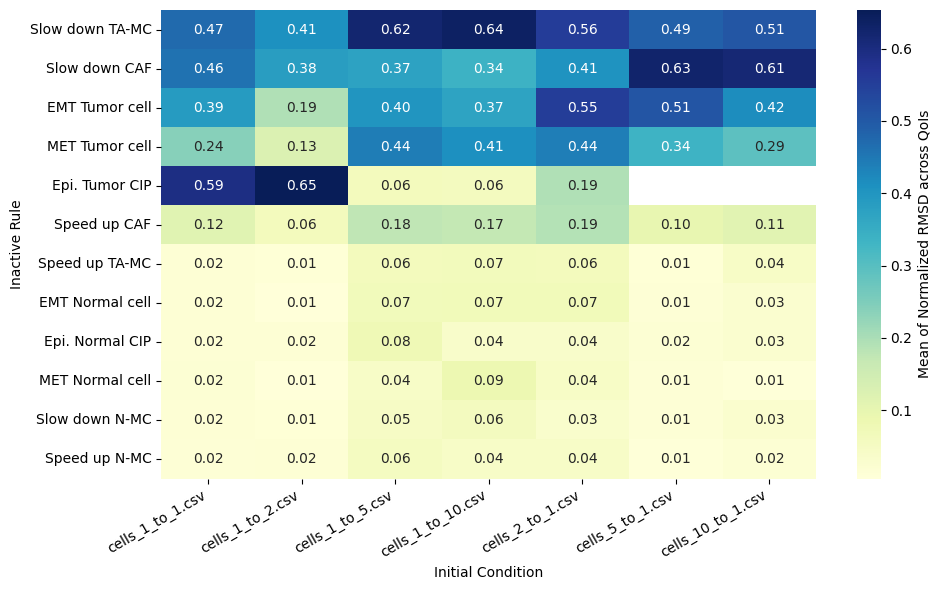

In [6]:
# Mean of normalized rmsd for all features per IC (take the mean across features for each sample)
df_mean_normalized_rmsd = df_rmsd_normalized[['IC_file', 'Inactive_rule']].copy()  # Start with a DataFrame containing IC_file and Inactive_rule
df_mean_normalized_rmsd["Mean of Normalized RMSD"] = 0.0
for ic in df_rmsd_normalized['IC_file'].unique():
    sampleids = df_rmsd_normalized.index[df_rmsd_normalized['IC_file'] == ic].tolist()
    df_mean_normalized_rmsd.loc[sampleids, "Mean of Normalized RMSD"] = df_rmsd_normalized.loc[sampleids, valid_columns].mean(axis=1)  # Take the mean across features for the current IC

# Define the ranking of rules based on the mean of normalized RMSD
df_ranked = pd.DataFrame(index=df_rmsd_normalized['Inactive_rule'].unique(), columns=['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'])
for inac_rule in df_rmsd_normalized['Inactive_rule'].unique():
    df_ranked.loc[inac_rule] = df_mean_normalized_rmsd[df_mean_normalized_rmsd['Inactive_rule'] == inac_rule]['Mean of Normalized RMSD'].describe()
df_ranked = df_ranked.sort_values(by='mean', ascending=False)
display(df_ranked)

# Plot the mean of normalized RMSD across features for each sample, colored by IC and grouped by Inactive_rule
fig, ax = plt.subplots(figsize=(10, 6))
df_mean_normalized_rmsd = df_mean_normalized_rmsd.sort_values(by="Mean of Normalized RMSD", ascending=False)
df_mean_normalized_rmsd_plot = df_mean_normalized_rmsd[df_mean_normalized_rmsd['Inactive_rule'].notna()]  # Drop rows where Inactive_rule is None
# sns.boxplot(data=df_mean_normalized_rmsd, x='Mean of Normalized RMSD', y='Inactive_rule', color='white', showfliers=False)
# sns.swarmplot(data=df_mean_normalized_rmsd, x='Mean of Normalized RMSD', y='Inactive_rule', hue='IC_file', hue_order=my_palette.keys(), palette=my_palette, dodge=True)
# ax.set(xlabel='Mean of Normalized RMSD across features', ylabel='Inactive Rule')
# plt.legend(title="Initial Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
heatmap_data = df_mean_normalized_rmsd_plot.pivot(index='Inactive_rule', columns='IC_file', values='Mean of Normalized RMSD').reindex(columns=ic_order, index=df_ranked[df_ranked.index.notna()].index)
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Mean of Normalized RMSD across QoIs'}, ax=ax)
ax.set(xlabel='Initial Condition', ylabel='Inactive Rule')
ax.set_xticklabels(ax.get_xticklabels(),rotation=30, ha='right') 
plt.tight_layout()
plt.savefig('CoCulture_MeanNormalizedRMSD.svg', format='svg')

## Cell snapshots — nominal vs top-sensitivity inactive rules

IC: cells_1_to_1.csv, Top samples for sensitivity analysis: [0, 56, 70, 42, 63]
IC: cells_1_to_2.csv, Top samples for sensitivity analysis: [1, 57, 71, 43, 64]
IC: cells_1_to_5.csv, Top samples for sensitivity analysis: [2, 72, 86, 65, 44]
IC: cells_1_to_10.csv, Top samples for sensitivity analysis: [3, 73, 87, 66, 45]
IC: cells_2_to_1.csv, Top samples for sensitivity analysis: [4, 74, 67, 88, 46]
IC: cells_5_to_1.csv, Top samples for sensitivity analysis: [5, 47, 68, 75, 89]
IC: cells_10_to_1.csv, Top samples for sensitivity analysis: [6, 48, 76, 69, 90]


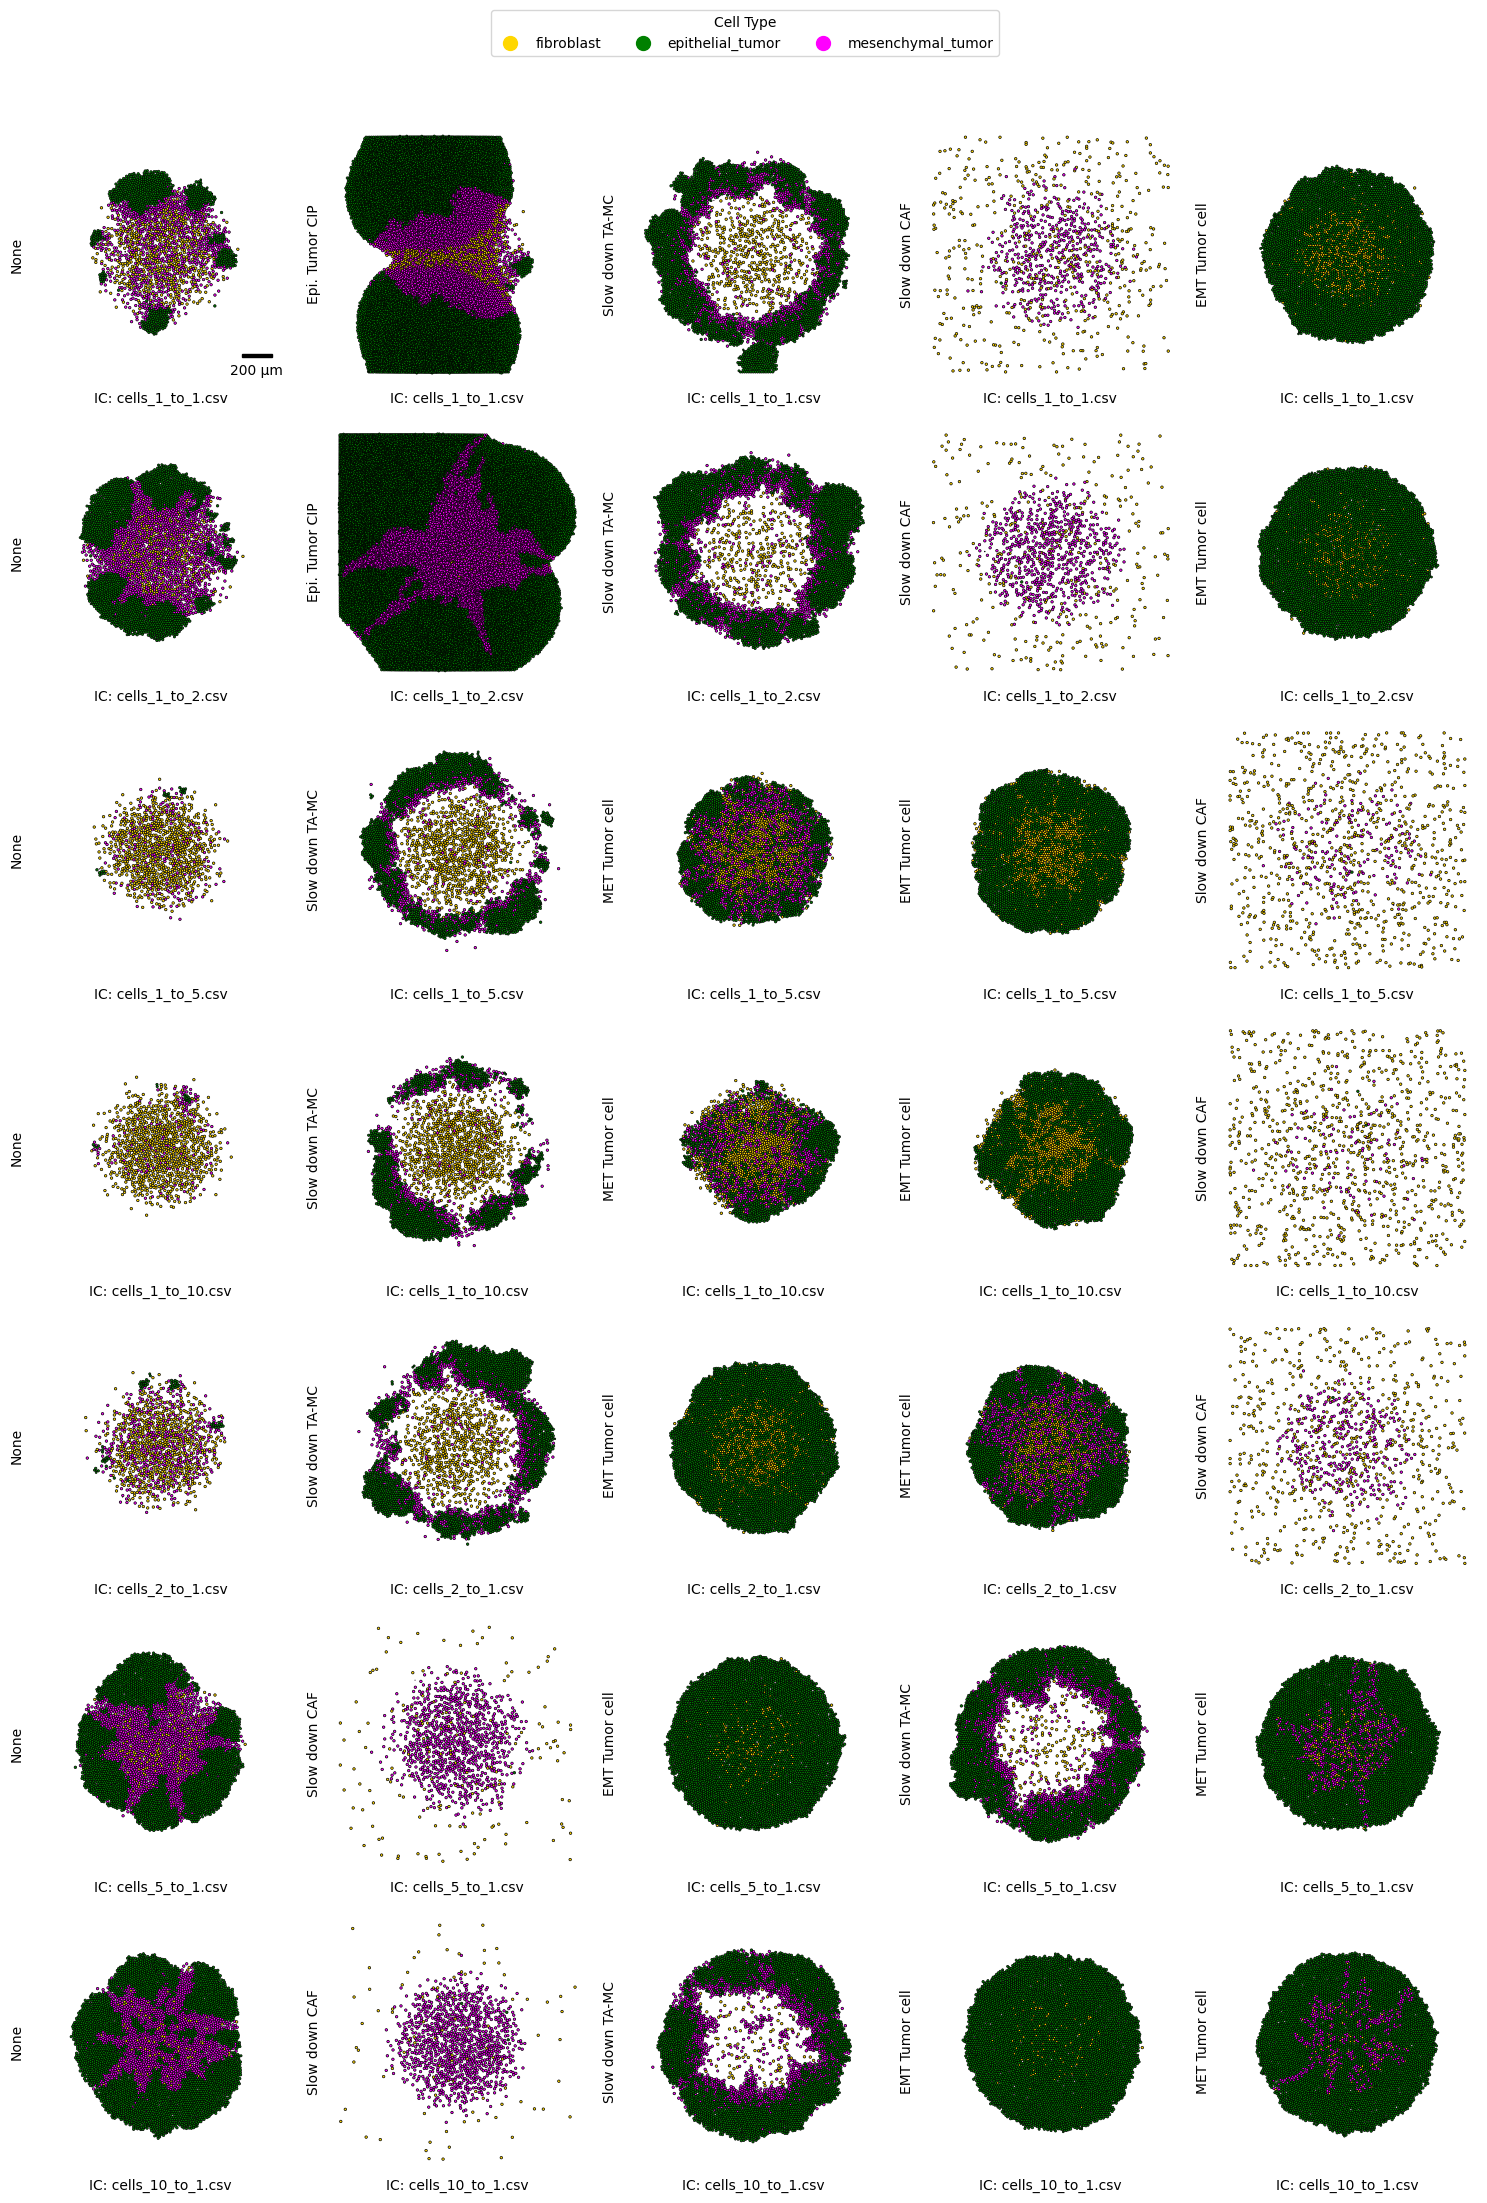

In [7]:
from uq_physicell.model_analysis import load_output, plot_cells_2D
from matplotlib.lines import Line2D

ICs = df_samples_desc['IC_file'].unique()
fig, axes = plt.subplots(len(ICs),5, figsize=(15, 3*len(ICs)), sharex=True, sharey=True)
max_labels = 0
color_dic = {'fibroblast': 'gold', 'epithelial_tumor': 'green', 'mesenchymal_tumor': 'magenta'}
particular_replicate_id = 0
for i, IC in enumerate(ICs):
    # First sample is the nominal case + top 4 max sensitivity inactive rules for the current IC
    top_samples_sensitivity = df_mean_normalized_rmsd.index[(df_mean_normalized_rmsd['IC_file'] == IC) & (df_mean_normalized_rmsd['Inactive_rule'].isna()) ].tolist()
    top_samples_sensitivity += df_mean_normalized_rmsd[df_mean_normalized_rmsd['IC_file'] == IC].sort_values(by='Mean of Normalized RMSD',ascending=False).head(4).index.tolist()
    print(f"IC: {IC}, Top samples for sensitivity analysis: {top_samples_sensitivity}")
    df_qois_data_selected = load_output(db_file, sample_ids=top_samples_sensitivity, replicate_ids=[particular_replicate_id], load_data=True)
    for j, sample in enumerate(top_samples_sensitivity):
        mcds = df_qois_data_selected[df_qois_data_selected['SampleID'] == sample].iloc[particular_replicate_id]['Data'][-1]
        df_cell = mcds.get_cell_df()
        plot_cells_2D(df_cell, color_dic, axes[i,j], scale_bar=True if (i==0 and j==0) else False)
        # Set axis labels and ticks
        axes[i,j].set(xlabel=f'IC: {IC}', ylabel=f'{df_mean_normalized_rmsd.loc[top_samples_sensitivity[j], "Inactive_rule"]}')
# Create legend elements
size_elements = [ Line2D([0], [0], marker='o', color=color_dic[label], label=label, markersize=10, linestyle='None') for label in color_dic.keys() ]
# Create a shared legend on the left side of the top
fig.legend(handles=size_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), title='Cell Type', ncol=len(color_dic))

plt.tight_layout()
plt.savefig('CoCulture_LastSnapshots.svg', format='svg')

0 - IC: cells_1_to_1.csv, Inactive rule: None, Cell count: 1000
1 - IC: cells_1_to_2.csv, Inactive rule: None, Cell count: 1000
2 - IC: cells_1_to_5.csv, Inactive rule: None, Cell count: 1000
3 - IC: cells_1_to_10.csv, Inactive rule: None, Cell count: 1000
4 - IC: cells_2_to_1.csv, Inactive rule: None, Cell count: 1000
5 - IC: cells_5_to_1.csv, Inactive rule: None, Cell count: 1000
6 - IC: cells_10_to_1.csv, Inactive rule: None, Cell count: 1000


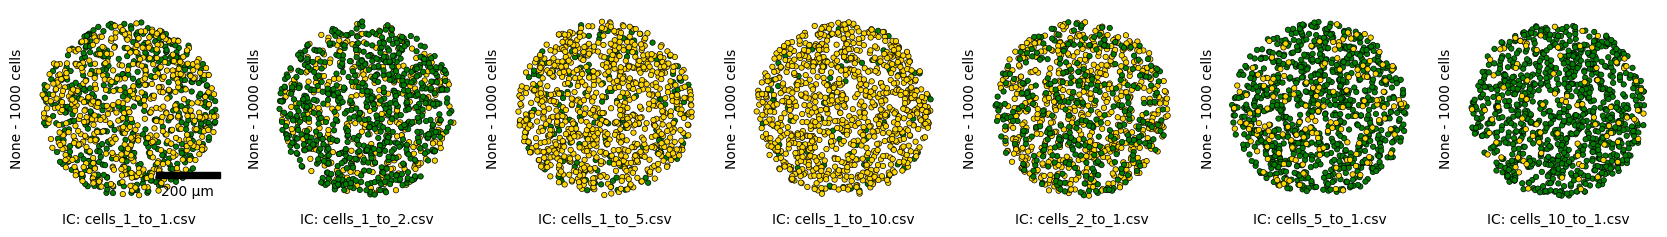

In [8]:
# Snapshots of the initial condition
fig, axes = plt.subplots(1,len(ICs), figsize=(21, 3), sharex=True, sharey=True)
ref_samples = df_mean_normalized_rmsd.index[df_mean_normalized_rmsd['Inactive_rule'].isna()].sort_values(ascending=True).tolist()
df_qois_data_selected = load_output(db_file, sample_ids=ref_samples, replicate_ids=[particular_replicate_id], load_data=True)
for i, IC in enumerate(ICs):
        mcds = df_qois_data_selected[df_qois_data_selected['SampleID'] == ref_samples[i]].iloc[particular_replicate_id]['Data'][0]
        df_cell = mcds.get_cell_df()
        plot_cells_2D(df_cell, color_dic, axes[i], scale_bar=True if (i==0) else False)
        # Set axis labels and ticks
        axes[i].set(xlabel=f'IC: {df_mean_normalized_rmsd.loc[ref_samples[i], "IC_file"]}', ylabel=f'{df_mean_normalized_rmsd.loc[ref_samples[i], "Inactive_rule"]} - {df_cell.shape[0]} cells')
        print(f"{ref_samples[i]} - IC: {df_mean_normalized_rmsd.loc[ref_samples[i], 'IC_file']}, Inactive rule: {df_mean_normalized_rmsd.loc[ref_samples[i], 'Inactive_rule']}, Cell count: {df_cell.shape[0]}")
plt.savefig('IC_Snapshots.svg', format='svg')

---
This notebook reproduces the rule inactivation analysis from [Johnson et al. 2025](https://doi.org/10.1016/j.cell.2025.06.048). The ranked RMSD table identifies which behavioral rules most strongly influence the model outputs across different tumor-to-fibroblast seeding ratios.